In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sleep_apnea_synthetic_data.csv")

In [ ]:
df.head()

,subject_id,night_id,epoch_index,age,bmi,acc_mean,acc_std,hr_mean,hr_std,spo2_mean,spo2_min,is_apnea_event,severity_label
0,S0000,S0000_N0,0,60,32.8,5.31,1.36,54.9,2.84,93.5,93.4,0.0,moderate
1,S0000,S0000_N0,1,60,32.8,5.70,0.71,53.8,1.89,95.3,93.9,0.0,moderate
2,S0000,S0000_N0,2,60,32.8,5.11,1.28,61.3,3.78,95.4,94.8,0.0,moderate
3,S0000,S0000_N0,3,60,32.8,5.00,1.28,56.9,2.24,94.7,93.1,0.0,moderate
4,S0000,S0000_N0,4,60,32.8,3.56,0.73,57.4,2.27,95.0,94.2,0.0,moderate


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (319786, 13)


In [ ]:
print(df.columns)

Index(['subject_id', 'night_id', 'epoch_index', 'age', 'bmi', 'acc_mean',
       'acc_std', 'hr_mean', 'hr_std', 'spo2_mean', 'spo2_min',
       'is_apnea_event', 'severity_label'],
      dtype='object')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319786 entries, 0 to 319785
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   subject_id      319786 non-null  object 
 1   night_id        319786 non-null  object 
 2   epoch_index     319786 non-null  int64  
 3   age             319786 non-null  int64  
 4   bmi             319786 non-null  float64
 5   acc_mean        319786 non-null  float64
 6   acc_std         319786 non-null  float64
 7   hr_mean         319786 non-null  float64
 8   hr_std          319786 non-null  float64
 9   spo2_mean       319786 non-null  float64
 10  spo2_min        319786 non-null  float64
 11  is_apnea_event  319785 non-null  float64
 12  severity_label  319785 non-null  object 
dtypes: float64(8), int64(2), object(3)
memory usage: 31.7+ MB


In [ ]:
df.describe()

,epoch_index,age,bmi,acc_mean,acc_std,hr_mean,hr_std,spo2_mean,spo2_min,is_apnea_event
count,319786.000000,319786.000000,319786.000000,319786.000000,319786.000000,319786.000000,319786.000000,319786.000000,319786.000000,319785.000000
mean,479.358462,47.552057,27.616747,9.016153,2.412871,68.749241,3.418555,94.564324,93.054865,0.200428
std,277.192040,14.742102,4.337390,7.156373,2.434352,10.321782,2.574380,3.412027,4.364502,0.400322
min,0.000000,18.000000,18.200000,0.000000,0.000000,40.000000,0.000000,81.200000,76.200000,0.000000
25%,239.000000,39.000000,24.100000,4.270000,0.820000,61.800000,1.630000,94.300000,93.100000,0.000000
50%,479.000000,48.000000,27.300000,6.130000,1.290000,67.300000,2.560000,95.700000,94.700000,0.000000
75%,719.000000,58.000000,30.800000,12.450000,3.750000,73.600000,4.670000,96.700000,95.700000,0.000000
max,959.000000,77.000000,39.600000,39.690000,12.290000,119.400000,15.120000,100.000000,99.700000,1.000000


In [ ]:
print(df.isnull().sum())

subject_id        0
night_id          0
epoch_index       0
age               0
bmi               0
acc_mean          0
acc_std           0
hr_mean           0
hr_std            0
spo2_mean         0
spo2_min          0
is_apnea_event    1
severity_label    1
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

subject_id: 67 unique values
night_id: 334 unique values
epoch_index: 960 unique values
age: 40 unique values
bmi: 51 unique values
acc_mean: 3688 unique values
acc_std: 1168 unique values
hr_mean: 751 unique values
hr_std: 1370 unique values
spo2_mean: 189 unique values
spo2_min: 234 unique values
is_apnea_event: 2 unique values
severity_label: 4 unique values


In [ ]:
print(df.dtypes)

subject_id         object
night_id           object
epoch_index         int64
age                 int64
bmi               float64
acc_mean          float64
acc_std           float64
hr_mean           float64
hr_std            float64
spo2_mean         float64
spo2_min          float64
is_apnea_event    float64
severity_label     object
dtype: object


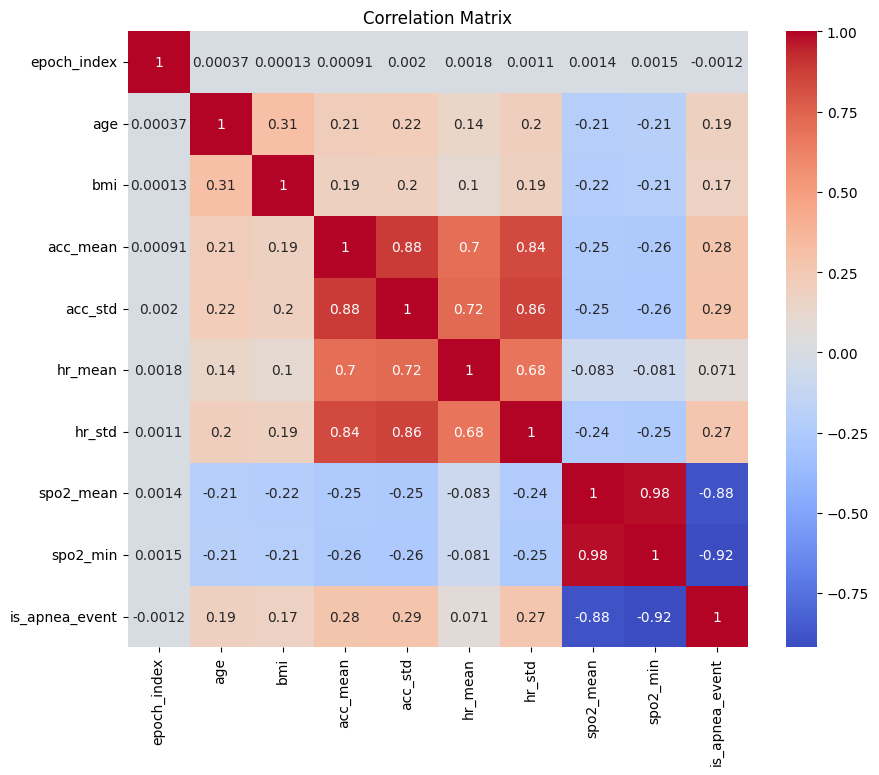

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

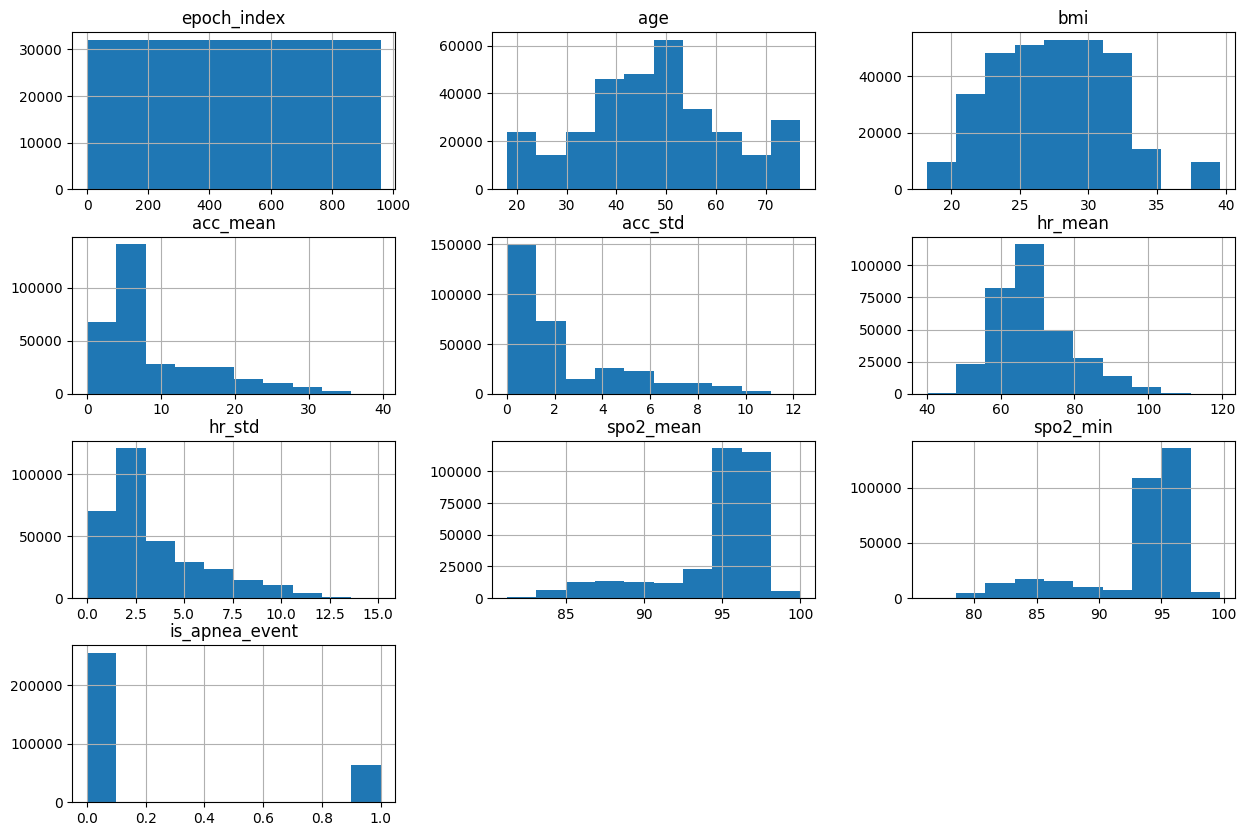

In [ ]:
df.hist(figsize=(15,10))
plt.show()

In [ ]:
from google.colab import files

# Save
df.to_csv("cleaned_sleep_apnea_dataset.csv", index=False)

# Download
files.download("cleaned_sleep_apnea_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

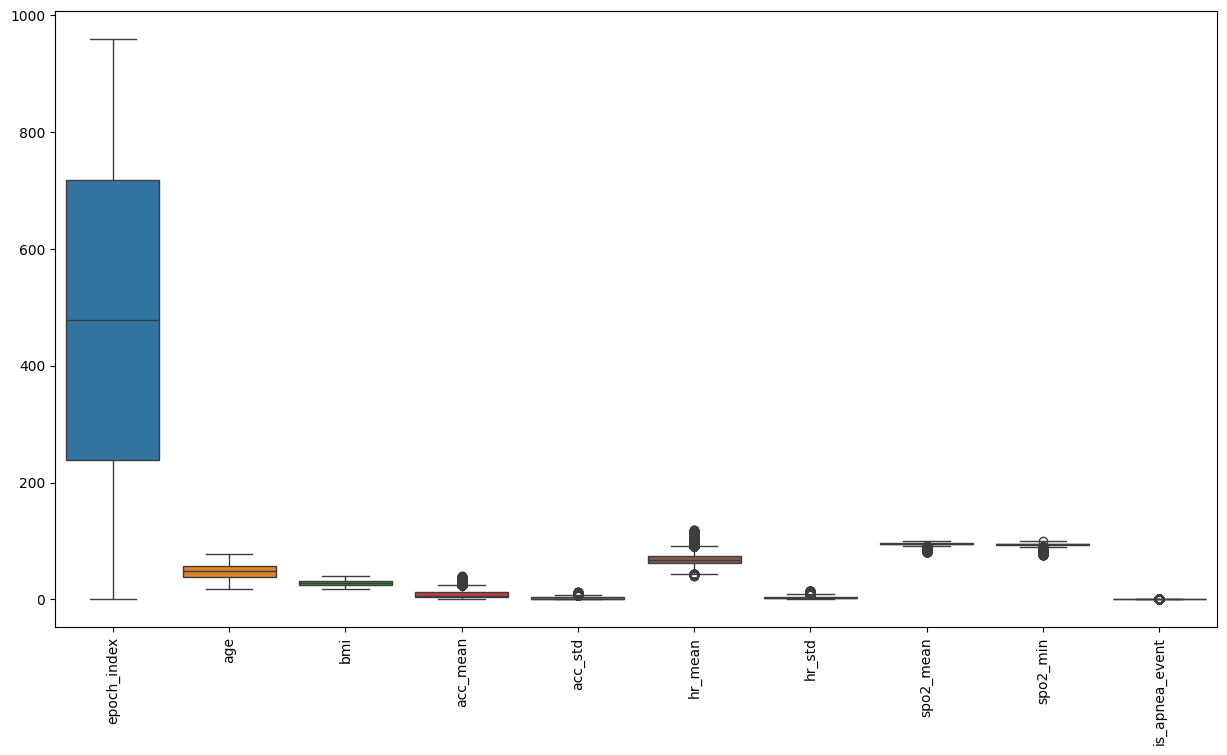

In [ ]:
import numpy as np

plt.figure(figsize=(15,8))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [10]:
# =====================================================
# CNN-LSTM Model for Sleep Apnea Severity Classification
# =====================================================

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("/content/cleaned_sleep_apnea_dataset (1).csv")
# Drop rows where 'severity_label' is NaN to prevent it from being encoded as a class
df.dropna(subset=['severity_label'], inplace=True)

print(df.head())

# =====================================================
# Remove Unnecessary Columns
# =====================================================

drop_cols = ["subject_id", "night_id"]

for col in drop_cols:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# =====================================================
# Features and Target
# =====================================================

X = df.drop("severity_label", axis=1)

y = df["severity_label"]

# =====================================================
# Encode Labels
# =====================================================

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Classes :", encoder.classes_)

# =====================================================
# Feature Scaling
# =====================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)

# =====================================================
# Reshape for CNN
# =====================================================

X = X.reshape(X.shape[0], X.shape[1], 1)

# =====================================================
# One Hot Encoding
# =====================================================

y = to_categorical(y)

# =====================================================
# Train Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
    # Removed stratify=y to avoid error when a class has only 1 member
)

# =====================================================
# Build CNN-LSTM Model
# =====================================================

model = Sequential()

model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation="relu",
    input_shape=(X_train.shape[1],1)
))

model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(32, activation="relu"))

model.add(Dense(len(encoder.classes_), activation="softmax")) # Use the correct number of classes

# =====================================================
# Compile Model
# =====================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =====================================================
# Train Model
# =====================================================

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

# =====================================================
# Evaluate
# =====================================================

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy :", accuracy)

# =====================================================
# Prediction
# =====================================================

pred = model.predict(X_test)

pred_class = np.argmax(pred, axis=1)

actual_class = np.argmax(y_test, axis=1)

# =====================================================
# Accuracy
# =====================================================

print("\nAccuracy")

print(accuracy_score(actual_class, pred_class))

# =====================================================
# Confusion Matrix
# =====================================================

cm = confusion_matrix(actual_class, pred_class)

print("\nConfusion Matrix")

print(cm)

# =====================================================
# Classification Report
# =====================================================

print("\nClassification Report")

print(classification_report(
    actual_class,
    pred_class,
    labels=range(len(encoder.classes_)), # Use range for labels
    target_names=encoder.classes_,
    zero_division=0
))

  subject_id  night_id  epoch_index   age   bmi  acc_mean  acc_std  hr_mean  \
0      S0000  S0000_N0          0.0  60.0  32.8      5.31     1.36     54.9   
1      S0000  S0000_N0          1.0  60.0  32.8      5.70     0.71     53.8   
2      S0000  S0000_N0          2.0  60.0  32.8      5.11     1.28     61.3   
3      S0000  S0000_N0          3.0  60.0  32.8      5.00     1.28     56.9   
4      S0000  S0000_N0          4.0  60.0  32.8      3.56     0.73     57.4   

   hr_std  spo2_mean  spo2_min  is_apnea_event severity_label  
0    2.84       93.5      93.4             0.0       moderate  
1    1.89       95.3      93.9             0.0       moderate  
2    3.78       95.4      94.8             0.0       moderate  
3    2.24       94.7      93.1             0.0       moderate  
4    2.27       95.0      94.2             0.0       moderate  
Classes : ['mild' 'moderate' 'none' 'severe']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 8, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,492 (138.64 KB)

 Trainable params: 35,492 (138.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6581 - loss: 0.8388 - val_accuracy: 0.7740 - val_loss: 0.5346
Epoch 2/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7958 - loss: 0.4821 - val_accuracy: 0.7962 - val_loss: 0.4260
Epoch 3/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8109 - loss: 0.4188 - val_accuracy: 0.8019 - val_loss: 0.3995
Epoch 4/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8169 - loss: 0.3959 - val_accuracy: 0.8121 - val_loss: 0.3885
Epoch 5/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8205 - loss: 0.3857 - val_accuracy: 0.8209 - val_loss: 0.3801
Epoch 6/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8206 - loss: 0.3797 - val_accuracy: 0.8199 - val_loss: 0.3733
Epoch 7/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8229 - loss: 0.3738 - val_accuracy: 0.8144 - val_loss: 0.3808
Epoch 8/20
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8238 - loss: 0.3698 - val_accuracy: 0

Distribution of Severity Labels:
severity_label
mild        16320
moderate     9258
none         6720
severe      14400
Name: count, dtype: int64


/tmp/ipykernel_715/2311733547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=severity_distribution.index, y=severity_distribution.values, palette='viridis')


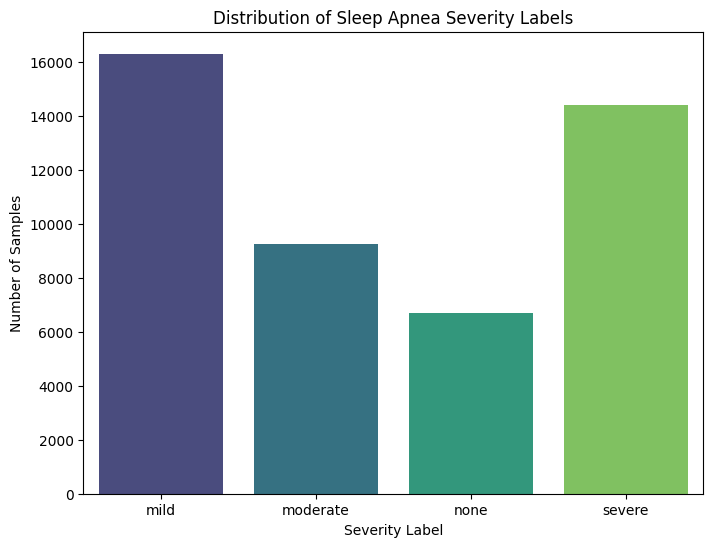

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the distribution of severity_label classes
severity_distribution = df['severity_label'].value_counts().sort_index()

print("Distribution of Severity Labels:")
print(severity_distribution)

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=severity_distribution.index, y=severity_distribution.values, palette='viridis')
plt.title('Distribution of Sleep Apnea Severity Labels')
plt.xlabel('Severity Label')
plt.ylabel('Number of Samples')
plt.show()